# Lightcurves Query
This notebook queries the SDSS QSO catalog, cross matches AGN to ZTF via the IRSA LC-API utility, then stores lightcurve bands in HDF5 and finally provides basic tools for their analysis.

**Cells in order:**
1. Config (TOML string — edit here)
2. Imports & logging
3. Filter profile plot (SDSS / ZTF / LSST)
4. Pipeline: SDSS query → ZTF fetch → HDF5 write
5. Analysis: metadata inspection, epoch filtering, lightcurve plot

In [1]:
import tomllib

TOML_CONFIG = """
[pipeline]
target_n             = 100          # desired number of successfully saved objects
oversample           = 2            # SDSS total objects queried = target_n * oversample
search_radius_arcsec = 3.0          # ZTF cone search radius
bad_catflags_mask    = 32768        # ZTF bad-epoch bitmask
request_delay_sec    = 0.5          # polite pause between IRSA requests
max_retries          = 3            # per request retry attempts
backoff_base_sec     = 2.0          # exponential backoff base (doubles each retry)
bands                = ["g", "r"]   # choice of color filters ("g" and "r" are always present, "i" is spotty and sparsely covered)

[storage]
output_hdf5  = "lc.h5"       # HDF5 file name
hdf5_lc_root = "lc"          # HDF5 group for lightcurves
hdf5_meta_key = "metadata"   # HDF5 key for metadata table

[analysis]
## epoch filters applied when selecting objects for inspection ##
min_g_epochs = 0
max_g_epochs = 99999
min_r_epochs = 0
max_r_epochs = 99999

## redshift and classification filters (empty string = no filter)
min_redshift  = 0.0
max_redshift  = 99.0
sdss_class    = ""        # e.g. "QSO"
sdss_subclass = ""        # e.g. "Seyfert", "BROADLINE", etc.

[filter_plot]
## axis limits ##
wl_min_angstrom = 3000
wl_max_angstrom = 11000
"""

cfg = tomllib.loads(TOML_CONFIG)
print(f"config loaded: target_n={cfg['pipeline']['target_n']}, "
      f"bands={cfg['pipeline']['bands']}, "
      f"output={cfg['storage']['output_hdf5']}")


config loaded: target_n=100, bands=['g', 'r'], output=lc.h5


In [2]:
%matplotlib inline
%config InlineBackend.figure_format = "svg"

import warnings, time, logging
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from astroquery.sdss import SDSS
from astroquery.svo_fps import SvoFps
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.io import ascii as astropy_ascii

try:
    from tables import NaturalNameWarning
    warnings.filterwarnings("ignore", category=NaturalNameWarning)
except ImportError:
    pass

## root logger (passes INFO to notebook but suppresses noisy sub loggers) ##
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%H:%M:%S",
    force=True,
)
log = logging.getLogger("ztf_pipeline")
logging.getLogger("astropy").setLevel(logging.WARNING)
logging.getLogger("astroquery").setLevel(logging.WARNING)
print("imports done")


imports done


fetching SDSS filter profile from SVO...


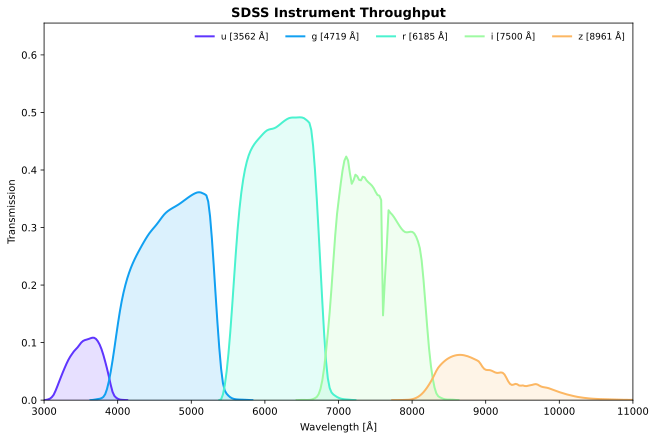

fetching LSST filter profile from SVO...


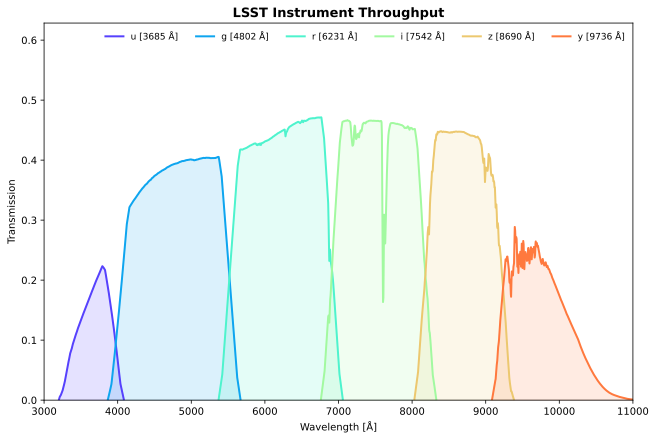

fetching ZTF filter profile from SVO...


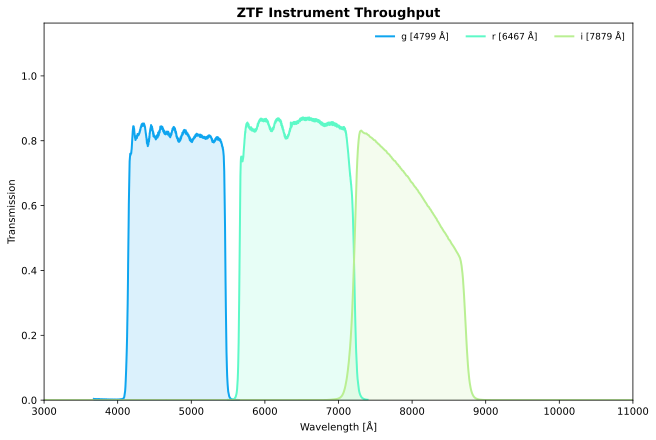

fetching SDSS filter profile from SVO...


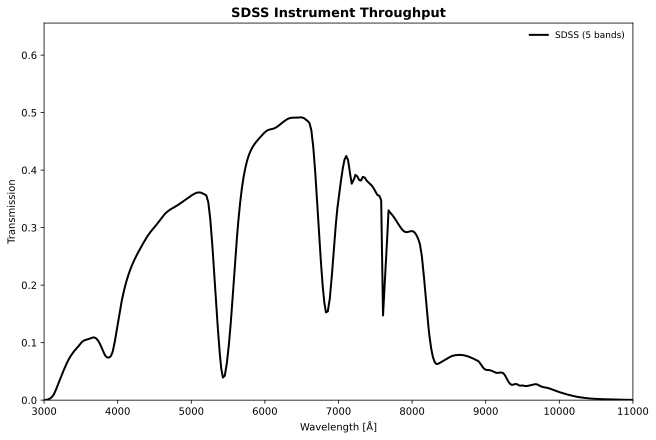

fetching LSST filter profile from SVO...


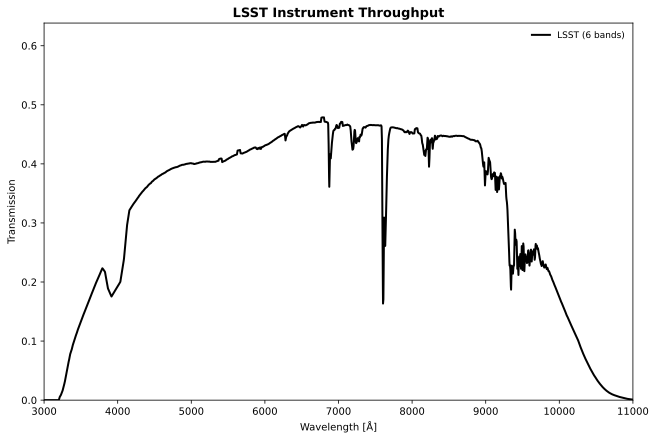

fetching ZTF filter profile from SVO...


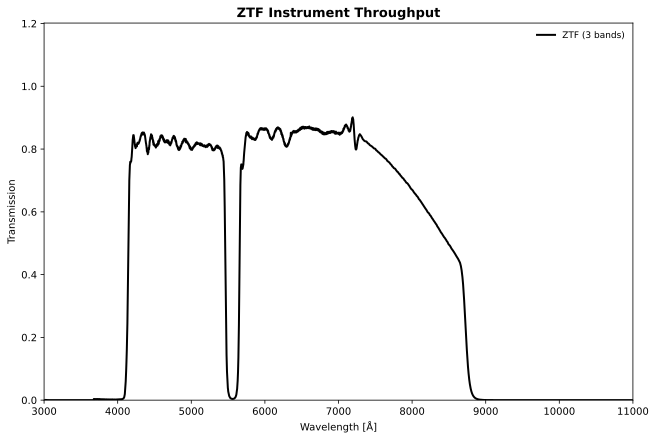

In [3]:
## filter profiles plot ##

FILTER_SURVEYS = {
    "SDSS": {"prefix": "SLOAN/SDSS.", "bands": ["u","g","r","i","z"]},
    "LSST": {"prefix": "LSST/LSST.",  "bands": ["u","g","r","i","z","y"]},
    "ZTF":  {"prefix": "Palomar/ZTF.", "bands": ["g","r","i"]},
}

WL_MIN = cfg["filter_plot"]["wl_min_angstrom"]
WL_MAX = cfg["filter_plot"]["wl_max_angstrom"]


def wl_to_color(wl: float) -> tuple:
    """
    Map wavelength (Angstroms) to rainbow colormap colour.
    """
    norm = np.clip((wl - WL_MIN) / (WL_MAX - WL_MIN), 0, 1)
    return plt.cm.rainbow(norm)


def central_wavelength(transmission_table) -> float:
    """
    Calculate transmission weighted mean wavelength from an SVO filter table.
    """
    wl = np.array(transmission_table["Wavelength"], dtype=float)
    tr = np.array(transmission_table["Transmission"], dtype=float)
    return float(np.average(wl, weights=np.clip(tr, 0, None)))


def plot_filter_profile(
    name: str,
    surveys: dict = FILTER_SURVEYS,
    wl_min: float = WL_MIN,
    wl_max: float = WL_MAX,
) -> None:
    """
    Fetch ZTF/SDSS/LSST filter transmission curve from SVO and plot it.
    Each filter is coloured by its transmission weighted central wavelength.
    """
    fig, axes = plt.subplots(
        nrows=1, ncols=1,
        figsize=(9, 6),
        constrained_layout=True,
    )
    ax = axes

    print(f"fetching {name} filter profile from SVO...")
    info = surveys[name]

    maxtr = 0.0
    for band in info["bands"]:
        filter_id = f"{info['prefix']}{band}"
        try:
            data = SvoFps.get_transmission_data(filter_id)
            wl = np.array(data["Wavelength"], dtype=float)
            tr = np.array(data["Transmission"], dtype=float)
            maxtr = (np.max(tr) if np.max(tr) > maxtr else maxtr)
            cwl  = central_wavelength(data)
            col  = wl_to_color(cwl)
            ax.plot(wl, tr, label=f"{band} [{cwl:.0f} Å]",
                    color=col, lw=2)
            ax.fill_between(wl, tr, alpha=0.15, color=col)
        except Exception as exc:
            print(f"  warning: could not fetch {filter_id}: {exc}")

    ax.set_title(f"{name} Instrument Throughput",
                 fontsize=13, fontweight="bold", loc="center")
    ax.set_ylabel("Transmission")
    ax.set_ylim(0, 4/3 * maxtr)
    ax.legend(loc="upper right", ncol=len(info["bands"]),
              framealpha=0.0, fontsize=9)

    ax.set_xlabel(r"Wavelength [Å]")
    ax.set_xlim(wl_min, wl_max)
    plt.savefig(f"assets/{name.lower()}_filter.pdf")
    plt.savefig(f"assets/{name.lower()}_filter.png", dpi=600)
    plt.show()
    plt.close()


def plot_filter_curve(
    name: str,
    surveys: dict = FILTER_SURVEYS,
    wl_min: float = WL_MIN,
    wl_max: float = WL_MAX,
    wl_grid_step: float = 1.0,
) -> None:
    """
    Fetch filter transmission curves for a single survey from SVO and plot
    the sum of all bands as a single black line.
    """
    fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
    print(f"fetching {name} filter profile from SVO...")

    info      = surveys[name]
    wl_common = np.arange(wl_min, wl_max + wl_grid_step, wl_grid_step)
    sum_tr    = np.zeros_like(wl_common)
    n_fetched = 0

    for band in info["bands"]:
        filter_id = f"{info['prefix']}{band}"
        try:
            data = SvoFps.get_transmission_data(filter_id)
            wl   = np.array(data["Wavelength"],   dtype=float)
            tr   = np.array(data["Transmission"], dtype=float)
            tr   = np.where(np.isfinite(tr), tr, 0.0)
            sum_tr += np.interp(wl_common, wl, tr, left=0.0, right=0.0)
            n_fetched += 1
        except Exception as exc:
            print(f"  warning: could not fetch {filter_id}: {exc}")

    ax.plot(wl_common, sum_tr, color="black", lw=2, label=f"{name} ({n_fetched} bands)")

    ax.set_title(f"{name} Instrument Throughput",
                 fontsize=13, fontweight="bold", loc="center")
    ax.set_ylabel("Transmission")
    ax.set_ylim(0, 4/3 * np.max(sum_tr) if n_fetched > 0 else 1)
    ax.set_xlabel(r"Wavelength [Å]")
    ax.set_xlim(wl_min, wl_max)
    ax.legend(loc="upper right", framealpha=0.0, fontsize=9)

    plt.savefig(f"assets/{name.lower()}_curve.pdf")
    plt.savefig(f"assets/{name.lower()}_curve.png", dpi=600)
    plt.show()
    plt.close()


plot_filter_profile("SDSS")
plot_filter_profile("LSST")
plot_filter_profile("ZTF")

plot_filter_curve("SDSS")
plot_filter_curve("LSST")
plot_filter_curve("ZTF")


In [4]:
## pipeline ##

## unpack config for convenience ##
_pc  = cfg["pipeline"]
_sc  = cfg["storage"]

TARGET_N           = _pc["target_n"]
OVERSAMPLE         = _pc["oversample"]
SEARCH_RADIUS_DEG  = _pc["search_radius_arcsec"] / 3600.0
BAD_CATFLAGS_MASK  = _pc["bad_catflags_mask"]
REQUEST_DELAY_SEC  = _pc["request_delay_sec"]
MAX_RETRIES        = _pc["max_retries"]
BACKOFF_BASE       = _pc["backoff_base_sec"]
BANDS              = _pc["bands"]

OUTPUT_HDF5    = Path(_sc["output_hdf5"])
HDF5_LC_ROOT   = _sc["hdf5_lc_root"]
HDF5_META_KEY  = _sc["hdf5_meta_key"]

ZTF_LC_API     = "https://irsa.ipac.caltech.edu/cgi-bin/ZTF/nph_light_curves"
ZTF_BAND_CODES = {"g": "zg", "r": "zr", "i": "zi"}


## SDSS query ##

def build_sdss_sql(limit: int, min_bestobjid: int = 0) -> str:
    """
    Build deterministic SDSS QSO SQL query.
    Uses WHERE bestobjid > min_bestobjid for pagination without OFFSET.
    """
    return f"""
    SELECT TOP {limit}
        s.bestobjid,
        s.ra,
        s.dec,
        s.z        AS redshift,
        s.class,
        s.subclass
    FROM SpecObj AS s
    WHERE
        s.class       = 'QSO'
        AND s.bestobjid IS NOT NULL
        AND s.bestobjid > {min_bestobjid}
    GROUP BY
        s.bestobjid, s.ra, s.dec, s.z, s.class, s.subclass
    ORDER BY
        s.bestobjid
    """


def query_sdss_batch(limit: int, min_bestobjid: int = 0) -> pd.DataFrame:
    """
    Fetch one batch of SDSS QSOs and return a deduplicated DataFrame.
    """
    sql = build_sdss_sql(limit, min_bestobjid)
    result = SDSS.query_sql(sql)
    if result is None or len(result) == 0:
        return pd.DataFrame()
    df = result.to_pandas()
    df = df.drop_duplicates(subset="bestobjid").reset_index(drop=True)
    # Ensure correct types
    df["bestobjid"] = df["bestobjid"].astype(np.int64)
    df["redshift"]  = pd.to_numeric(df["redshift"], errors="coerce")
    return df


## ZTF IRSA fetch with retry ##

def fetch_ztf_lc(ra: float, dec: float) -> pd.DataFrame | None:
    """
    Conesearch IRSA ZTF LC-API and return raw epoch DataFrame or None.
    """
    band_str = ",".join(BANDS)
    params = {
        "POS":               f"CIRCLE {ra} {dec} {SEARCH_RADIUS_DEG}",
        "BANDNAME":          band_str,
        "BAD_CATFLAGS_MASK": BAD_CATFLAGS_MASK,
        "FORMAT":            "ipac_table",
    }
    try:
        resp = requests.get(ZTF_LC_API, params=params, timeout=30)
        resp.raise_for_status()
    except requests.RequestException as exc:
        raise ConnectionError(str(exc)) from exc

    if not resp.text.strip() or "oid" not in resp.text:
        return None

    table = astropy_ascii.read(resp.text, format="ipac")
    if len(table) == 0:
        return None

    df = table.to_pandas()
    for col in ("ra", "dec", "hjd", "mag", "magerr", "catflags", "oid"):
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def fetch_ztf_lc_with_retry(ra: float, dec: float) -> pd.DataFrame | None:
    """
    Wrap fetch_ztf_lc with exponential backoff retries.
    """
    for attempt in range(MAX_RETRIES):
        try:
            return fetch_ztf_lc(ra, dec)
        except Exception as exc:
            wait = BACKOFF_BASE ** attempt
            log.warning(
                "  IRSA error (attempt %d/%d): %s — retrying in %.0fs",
                attempt + 1, MAX_RETRIES, exc, wait,
            )
            time.sleep(wait)
    log.error("  all %d retries exhausted for RA=%.5f DEC=%.5f", MAX_RETRIES, ra, dec)
    return None


## band matching & lightcurve assembly ##

def select_best_oid_per_band(
    lc_df: pd.DataFrame, ra: float, dec: float
) -> dict[str, int | None]:
    """
    For each requested band, pick the ZTF oid whose median position is
    closest to (ra, dec). Returns {band_code: oid_or_None}.
    """
    source_coord = SkyCoord(ra=ra * u.deg, dec=dec * u.deg)
    result = {ZTF_BAND_CODES[b]: None for b in BANDS}

    for band_code in result:
        band_df = lc_df[lc_df["filtercode"] == band_code]
        best_oid, best_sep = None, np.inf
        for oid, grp in band_df.groupby("oid"):
            coord = SkyCoord(
                ra=grp["ra"].median() * u.deg,
                dec=grp["dec"].median() * u.deg,
            )
            sep = source_coord.separation(coord).arcsec
            if sep < best_sep:
                best_sep = sep
                best_oid = oid
        result[band_code] = best_oid

    return result


def build_merged_lightcurve(
    lc_df: pd.DataFrame,
    oids:  dict[str, int | None],
) -> pd.DataFrame | None:
    """
    Build a time union DataFrame from the best oid for each band.
    Columns: time_g, mag_g, magerr_g, time_r, mag_r, magerr_r
    Each row is one epoch in one band; the other band columns are NaN.
    No scalar metadata (oids, redshift) is stored here.
    """
    frames = []
    band_map = {"zg": ("g", "time_g","mag_g","magerr_g"),
                "zr": ("r", "time_r","mag_r","magerr_r"),
                "zi": ("i", "time_i","mag_i","magerr_i")}

    for band_code, (_, tcol, mcol, ecol) in band_map.items():
        if band_code not in oids or oids[band_code] is None:
            continue
        sub = lc_df[lc_df["oid"] == oids[band_code]][
            ["hjd","mag","magerr"]
        ].copy()
        sub = sub.rename(columns={"hjd": tcol, "mag": mcol, "magerr": ecol})
        frames.append(sub.reset_index(drop=True))

    if not frames:
        return None

    merged = pd.concat(frames, axis=0, ignore_index=True)
    time_cols = [c for c in merged.columns if c.startswith("time_")]
    merged["_t"] = merged[time_cols].bfill(axis=1).iloc[:, 0]
    merged = (
        merged.sort_values("_t")
              .drop(columns="_t")
              .reset_index(drop=True)
    )
    return merged


## HDF5 I/O ##

def save_lightcurve(bestobjid: int, lc: pd.DataFrame,
                    store: pd.HDFStore) -> None:
    key = f"/{HDF5_LC_ROOT}/{bestobjid}"
    store.put(key, lc, format="fixed")


def save_metadata(meta_rows: list[dict], store: pd.HDFStore) -> None:
    """
    Write (or overwrite) the metadata table into the HDFStore.
    Columns: bestobjid, ra, dec, redshift, class, subclass,
             oid_g, oid_r  (and oid_i if "i" band enabled)
    """
    meta_df = pd.DataFrame(meta_rows)
    meta_df["bestobjid"] = meta_df["bestobjid"].astype(np.int64)
    store.put(f"/{HDF5_META_KEY}", meta_df, format="fixed")


## main pipeline loop ##

def run_pipeline() -> pd.DataFrame:
    """
    Run the full acquisition pipeline.
    Returns the metadata DataFrame for immediate inspection.
    Stops and warns if the SDSS queue is exhausted before TARGET_N saves.
    """
    batch_size     = TARGET_N * OVERSAMPLE
    saved          = 0
    n_no_ztf       = 0
    n_retry_fail   = 0
    min_bestobjid  = 0
    meta_rows      = []
    seen_bestobjids = set()

    log.info(
        "starting pipeline: target_n=%d, oversample=%d, batch_size=%d",
        TARGET_N, OVERSAMPLE, batch_size,
    )

    with pd.HDFStore(OUTPUT_HDF5, mode="a", complevel=5,
                 complib="blosc") as store:

        ## load already saved bestobjids to skip duplicates across runs ##
        meta_key = f"/{HDF5_META_KEY}"
        if meta_key in store:
            existing = store[meta_key]["bestobjid"].astype(np.int64).tolist()
            seen_bestobjids.update(existing)
            saved = len(existing)
            log.info("resuming: %d objects already in store", saved)
    
        while saved < TARGET_N:
            log.info(
                "fetching SDSS batch (limit=%d, min_bestobjid=%d) …",
                batch_size, min_bestobjid,
            )
            sdss_df = query_sdss_batch(batch_size, min_bestobjid)

            if sdss_df.empty:
                log.warning(
                    "SDSS queue exhausted after %d saves (target was %d). "
                    "consider raising oversample or lowering target_n.",
                    saved, TARGET_N,
                )
                break

            ## update pagination cursor to the last bestobjid in this batch ##
            min_bestobjid = int(sdss_df["bestobjid"].max())

            for _, row in sdss_df.iterrows():
                if saved >= TARGET_N:
                    break

                bestobjid = int(row["bestobjid"])
                if bestobjid in seen_bestobjids:
                    continue
                seen_bestobjids.add(bestobjid)

                ra, dec = float(row["ra"]), float(row["dec"])
                log.info(
                    "[%4d/%d] bestobjid=%d  RA=%.5f  DEC=%.5f",
                    saved + 1, TARGET_N, bestobjid, ra, dec,
                )

                ## ZTF fetch with retry ##
                lc_df = fetch_ztf_lc_with_retry(ra, dec)
                time.sleep(REQUEST_DELAY_SEC)

                if lc_df is None or lc_df.empty:
                    log.debug("  → no ZTF detections")
                    n_no_ztf += 1
                    continue

                ## best oid per band ##
                oids = select_best_oid_per_band(lc_df, ra, dec)
                if all(v is None for v in oids.values()):
                    n_no_ztf += 1
                    continue

                ## build timeseries ##
                lc = build_merged_lightcurve(lc_df, oids)
                if lc is None or lc.empty:
                    n_retry_fail += 1
                    continue

                ## write lightcurve (pure timeseries, no scalars) ##
                lc_key = f"/{HDF5_LC_ROOT}/{bestobjid}"
                if lc_key in store:
                    log.warning("  → %d already in store, skipping", bestobjid)
                    continue
                save_lightcurve(bestobjid, lc, store)

                ## accumulate metadata (all scalars live here) ##
                meta_row = {
                    "bestobjid": bestobjid,
                    "ra":        ra,
                    "dec":       dec,
                    "redshift":  float(row["redshift"])
                              if pd.notna(row["redshift"]) else np.nan,
                    "sdss_class":    str(row.get("class", "")),
                    "sdss_subclass": str(row.get("subclass", "")),
                }
                ## one oid column per band (None → NaN) ##
                for band_code, oid_val in oids.items():
                    band_letter = band_code[1]  # "zg" → "g"
                    meta_row[f"oid_{band_letter}"] = (
                        int(oid_val) if oid_val is not None else pd.NA
                    )

                meta_row["g_epochs"] = int(lc["mag_g"].notna().sum()) \
                    if "mag_g" in lc.columns else 0
                meta_row["r_epochs"] = int(lc["mag_r"].notna().sum()) \
                    if "mag_r" in lc.columns else 0

                meta_rows.append(meta_row)
                saved += 1

                log.info(
                    "  → saved (%d/%d)  oid_g=%s  oid_r=%s  "
                    "g=%d epochs  r=%d epochs",
                    saved, TARGET_N,
                    oids.get("zg"), oids.get("zr"),
                    meta_row["g_epochs"], meta_row["r_epochs"],
                )

        ## write metadata table, merging with any existing rows ##
        if meta_rows:
            new_meta = pd.DataFrame(meta_rows)
            if meta_key in store:
                old_meta = store[meta_key]
                combined = pd.concat([old_meta, new_meta], ignore_index=True)
                combined = combined.drop_duplicates(subset="bestobjid").reset_index(drop=True)
            else:
                combined = new_meta
            combined["bestobjid"] = combined["bestobjid"].astype(np.int64)
            store.put(meta_key, combined, format="fixed")
            log.info("metadata table written (%d rows total).", len(combined))

    log.info("=" * 60)
    log.info("pipeline complete")
    log.info("  saved        : %d / %d", saved, TARGET_N)
    log.info("  no ZTF match : %d", n_no_ztf)
    log.info("  other skips  : %d", n_retry_fail)
    log.info("  output       : %s", OUTPUT_HDF5)
    log.info("=" * 60)

    return pd.DataFrame(meta_rows)


metadata = run_pipeline()


07:12:34  INFO      starting pipeline: target_n=100, oversample=2, batch_size=200
07:12:34  INFO      fetching SDSS batch (limit=200, min_bestobjid=0) …
07:12:34  INFO      [   1/100] bestobjid=1197126704423239975  RA=238.23135  DEC=55.93361
07:12:57  INFO        → saved (1/100)  oid_g=794110100014215  oid_r=794210100017828  g=1151 epochs  r=1281 epochs
07:12:57  INFO      [   2/100] bestobjid=1197126704428810393  RA=238.55945  DEC=43.16305
07:13:13  INFO        → saved (2/100)  oid_g=721113300015990  oid_r=721213300002028  g=1010 epochs  r=1129 epochs
07:13:13  INFO      [   3/100] bestobjid=1197126704428875838  RA=238.43512  DEC=43.10423
07:13:31  INFO        → saved (3/100)  oid_g=721113300006600  oid_r=721213300002536  g=1275 epochs  r=1319 epochs
07:13:31  INFO      [   4/100] bestobjid=1197126704428875872  RA=238.49717  DEC=43.15542
07:13:50  INFO        → saved (4/100)  oid_g=721113300001248  oid_r=721213300002106  g=1242 epochs  r=1309 epochs
07:13:50  INFO      [   5/100] best

total objects in store: 100
              bestobjid  redshift        sdss_subclass  g_epochs  r_epochs
0   1197126704423239975  0.338289            BROADLINE      1151      1281
1   1197126704428810393  1.770023                  nan      1010      1129
2   1197126704428875838  2.640425            BROADLINE      1275      1319
3   1197126704428875872  0.546075            BROADLINE      1242      1309
4   1197126705520378125  1.413118                  nan       354        15
5   1197126709252456640  3.959372            BROADLINE       576      1165
6   1197128457305653413  1.811673            BROADLINE       621       681
7   1197128466986893403  1.732260            BROADLINE        22       626
8   1197128707508338876  1.120811            BROADLINE        24        37
9   1197131404758811462  0.485411                  nan       649        83
10  1197131405287686402  2.659334            BROADLINE       768       898
11  1197131412782777521  0.929065                  nan       605       9

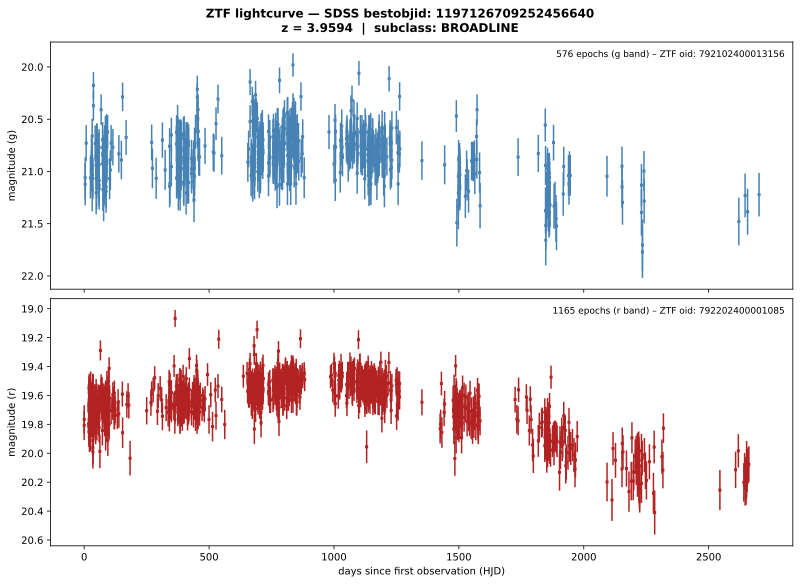

In [5]:
## initial selection script ##

_ac = cfg["analysis"]


def load_metadata(file_path: str | Path = OUTPUT_HDF5) -> pd.DataFrame:
    """Read the metadata table from HDF5."""
    return pd.read_hdf(file_path, key=f"/{HDF5_META_KEY}")


def filter_catalog(
    meta_df:       pd.DataFrame,
    min_g:         int   | None = None,
    max_g:         int   | None = None,
    min_r:         int   | None = None,
    max_r:         int   | None = None,
    min_redshift:  float | None = None,
    max_redshift:  float | None = None,
    sdss_class:    str   | None = None,
    sdss_subclass: str   | None = None,
) -> pd.DataFrame:
    min_g         = _ac["min_g_epochs"]  if min_g         is None else min_g
    max_g         = _ac["max_g_epochs"]  if max_g         is None else max_g
    min_r         = _ac["min_r_epochs"]  if min_r         is None else min_r
    max_r         = _ac["max_r_epochs"]  if max_r         is None else max_r
    min_redshift  = _ac["min_redshift"]  if min_redshift  is None else min_redshift
    max_redshift  = _ac["max_redshift"]  if max_redshift  is None else max_redshift
    sdss_class    = _ac["sdss_class"]    if sdss_class    is None else sdss_class
    sdss_subclass = _ac["sdss_subclass"] if sdss_subclass is None else sdss_subclass
    """
    Filter the metadata catalog by epoch counts, redshift, and
    SDSS classification. All bounds are inclusive.
    Empty string for sdss_class / sdss_subclass means no filter.
    Returns a reset indexed sub DataFrame.
    """
    mask = (
        (meta_df["g_epochs"] >= min_g) &
        (meta_df["g_epochs"] <= max_g) &
        (meta_df["r_epochs"] >= min_r) &
        (meta_df["r_epochs"] <= max_r) &
        (meta_df["redshift"] >= min_redshift) &
        (meta_df["redshift"] <= max_redshift)
    )
    if sdss_class:
        mask &= meta_df["sdss_class"].str.upper() == sdss_class.upper()
    if sdss_subclass:
        mask &= (meta_df["sdss_subclass"]
                 .str.upper()
                 .str.contains(sdss_subclass.upper(), na=False))
    return meta_df[mask].reset_index(drop=True)


def load_lightcurve(
    bestobjid: int,
    file_path: str | Path = OUTPUT_HDF5,
) -> pd.DataFrame:
    """
    Load a single object's timeseries DataFrame from HDF5.
    """
    key = f"/{HDF5_LC_ROOT}/{bestobjid}"
    return pd.read_hdf(file_path, key=key)


def plot_lightcurve(
    filtered_df: pd.DataFrame,
    index:       int = 0,
    file_path:   str | Path = OUTPUT_HDF5,
) -> tuple[np.ndarray, ...]:
    """
    Plot "g" and "r" band lightcurves for the object at `index` in
    the filtered metadata DataFrame.  Time is zeroed to the
    earliest observation across both bands.

    Returns (t_g, m_g, e_g, t_r, m_r, e_r) as clean NumPy arrays
    (NaN rows dropped, so arrays are not co indexed).
    """
    if index >= len(filtered_df):
        raise IndexError(
            f"index={index} out of range for filtered catalog "
            f"of {len(filtered_df)} objects."
        )

    row       = filtered_df.iloc[index]
    bid       = int(row["bestobjid"])
    oid_g     = row.get("oid_g", None)
    oid_r     = row.get("oid_r", None)
    redshift  = row.get("redshift", np.nan)
    subclass  = row.get("sdss_subclass", "")

    df = load_lightcurve(bid, file_path)

    ## extract clean arrays in each band ##
    def _extract(df, tcol, mcol, ecol):
        if tcol not in df.columns:
            return np.array([]), np.array([]), np.array([])
        sub = df[[tcol, mcol, ecol]].dropna()
        return sub[tcol].to_numpy(), sub[mcol].to_numpy(), sub[ecol].to_numpy()

    t_g, m_g, e_g = _extract(df, "time_g", "mag_g", "magerr_g")
    t_r, m_r, e_r = _extract(df, "time_r", "mag_r", "magerr_r")

    ## zero time to the global first observation ##
    all_times = np.concatenate([
        t_g if len(t_g) else [],
        t_r if len(t_r) else [],
    ])
    t0 = float(np.min(all_times)) if len(all_times) > 0 else 0.0
    t_g_z = t_g - t0
    t_r_z = t_r - t0

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True, constrained_layout=True)

    subtitle = (
        f"z = {redshift:.4f}" if not np.isnan(float(redshift)) else "z = N/A"
    )
    if subclass:
        subtitle += (
            f"  |  subclass: {subclass}" if subclass != 'nan' else "  |  subclass: N/A"
        )

    fig.suptitle(
        f"ZTF lightcurve — SDSS bestobjid: {bid}\n{subtitle}",
        fontsize=12, fontweight="bold",
    )

    # g band
    if len(t_g_z) > 0:
        ax1.errorbar(
            t_g_z, m_g, yerr=e_g, fmt="s",
            color="steelblue",
            markersize=2, alpha=1,
        )
        ax1.plot([], [], ' ', label=f"{len(t_g_z)} epochs (g band) – ZTF oid: {oid_g}")
        ax1.invert_yaxis()
        ax1.set_ylabel("magnitude (g)")
        ax1.legend(loc="upper right", framealpha=0.0, fontsize=9)
    else:
        ax1.text(0.5, 0.5, "no valid g band observations",
                 transform=ax1.transAxes, ha="center", color="grey")

    # r band
    if len(t_r_z) > 0:
        ax2.errorbar(
            t_r_z, m_r, yerr=e_r, fmt="s",
            color="firebrick",
            markersize=2, alpha=1,
        )
        ax2.plot([], [], ' ', label=f"{len(t_r_z)} epochs (r band) – ZTF oid: {oid_r}")
        ax2.invert_yaxis()
        ax2.set_ylabel("magnitude (r)")
        ax2.set_xlabel("days since first observation (HJD)")
        ax2.legend(loc="upper right", framealpha=0.0, fontsize=9)
    else:
        ax2.text(0.5, 0.5, "no valid r band observations",
                 transform=ax2.transAxes, ha="center", color="grey")
        ax2.set_xlabel("days since first observation (HJD)")

    plt.show()
    plt.close()

    return t_g, m_g, e_g, t_r, m_r, e_r


## reload metadata from file ##
metadata = load_metadata()
print(f"total objects in store: {len(metadata)}")
print(metadata[["bestobjid","redshift","sdss_subclass",
                 "g_epochs","r_epochs"]].to_string())

## apply filters from config ##
filtered = filter_catalog(metadata, min_r=1100, max_g=900)
print(f"\nobjects passing filters: {len(filtered)}")
print(filtered[["bestobjid","redshift","sdss_subclass",
                 "g_epochs","r_epochs"]].to_string())
print()

## plot object at chosen index of the filtered set and get clean arrays ##
if not filtered.empty:
    t_g, m_g, e_g, t_r, m_r, e_r = plot_lightcurve(filtered, index=0)
else:
    print("no objects pass current filter criteria.")
